In [52]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
from sklearn.metrics import precision_recall_fscore_support
from sklearn.metrics.pairwise import cosine_similarity


In [53]:
from cosine_sim_two_part import *

In [54]:
def predict_top_k(similarity, k):
    pred = np.zeros_like(similarity, dtype=np.uint8)

    if k <= 0:
        return pred

    k = min(k, similarity.shape[1])

    topk_idx = np.argpartition(-similarity, kth=k-1, axis=1)[:, :k]
    row_idx = np.arange(similarity.shape[0])[:, None]
    pred[row_idx, topk_idx] = 1

    return pred

In [55]:
def prepare_acc_val_problem_from_split_files(
    labels_csv="../data/acc/audit_tax_accounting_jobs.csv",
    jobs_embeddings_jsonl="../embedding/acc/acc_jobs_embeddings.jsonl",
    skills_embeddings_jsonl="../embedding/acc/acc_skills_embeddings.jsonl",
    split="val",
):
    labels_df = pd.read_csv(
        labels_csv,
        usecols=["uuid", "title", "extracted_skills"]
    ).rename(columns={"uuid": "job_id", "title": "label_title"})

    jobs_embeddings = pd.read_json(jobs_embeddings_jsonl, lines=True)
    skills_embeddings = pd.read_json(skills_embeddings_jsonl, lines=True)

    jobs_split = jobs_embeddings.loc[jobs_embeddings["split"] == split].reset_index(drop=True)

    merged = jobs_split.merge(
        labels_df,
        on="job_id",
        how="left",
    )

    missing_labels = merged["label_title"].isna().sum()
    if missing_labels:
        raise ValueError(f"{missing_labels} rows in split={split} have no matching labels")

    merged["title"] = merged["label_title"].fillna(merged.get("title", "")).astype(str)
    merged["actual_skill_lists"] = merged["extracted_skills"].map(parse_skill_list)

    skill_names = skills_embeddings["skill_name"].tolist()

    job_matrix = np.vstack(merged["embedding"].to_numpy()).astype(np.float32)
    skill_matrix = np.vstack(skills_embeddings["embedding"].to_numpy()).astype(np.float32)

    similarity = cosine_similarity(job_matrix, skill_matrix)
    labels = build_indicator_matrix(merged["actual_skill_lists"].tolist(), skill_names)

    if similarity.shape != labels.shape:
        raise ValueError(
            f"Similarity matrix shape {similarity.shape} does not match label matrix shape {labels.shape}"
        )

    problem = {
        "entities_df": merged[["job_id", "title", "actual_skill_lists"]].rename(
            columns={"job_id": "entity_id"}
        ).assign(entity_type="job")[["entity_type", "entity_id", "title", "actual_skill_lists"]].reset_index(drop=True),
        "skill_names": skill_names,
        "similarity": similarity,
        "labels": labels,
    }

    return problem, jobs_embeddings, jobs_split, skills_embeddings

In [56]:
def build_topk_result_frames(problem, predictions, dataset_variant, best_k):
    entities_df = problem["entities_df"]
    skill_names = problem["skill_names"]
    labels = problem["labels"]

    micro_precision, micro_recall, micro_f1, _ = precision_recall_fscore_support(
        labels.ravel(),
        predictions.ravel(),
        average="binary",
        zero_division=0,
    )

    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="macro",
        zero_division=0,
    )

    predicted_skill_lists = [
        [skill_names[idx] for idx, is_on in enumerate(row) if is_on]
        for row in predictions
    ]
    actual_skill_lists = entities_df["actual_skill_lists"].tolist()

    metrics_df = pd.DataFrame([{
        "dataset_variant": dataset_variant,
        "model_variant": "top_k",
        "num_jobs": len(entities_df),
        "num_skills": len(skill_names),
        "best_k": int(best_k),
        "micro_precision": float(micro_precision),
        "micro_recall": float(micro_recall),
        "micro_f1": float(micro_f1),
        "macro_precision": float(macro_precision),
        "macro_recall": float(macro_recall),
        "macro_f1": float(macro_f1),
    }])

    predictions_df = pd.DataFrame({
        "entity_id": entities_df["entity_id"],
        "title": entities_df["title"],
        "actual_skills": [" | ".join(skills) for skills in actual_skill_lists],
        "predicted_skills": [" | ".join(skills) for skills in predicted_skill_lists],
        "tp": [len(set(a) & set(p)) for a, p in zip(actual_skill_lists, predicted_skill_lists)],
        "fp": [len(set(p) - set(a)) for a, p in zip(actual_skill_lists, predicted_skill_lists)],
        "fn": [len(set(a) - set(p)) for a, p in zip(actual_skill_lists, predicted_skill_lists)],
    })

    return metrics_df, predictions_df

In [57]:
def fit_top_k_model(problem, *, dataset_variant, candidate_k_values=None):
    similarity = problem["similarity"]
    labels = problem["labels"]

    if candidate_k_values is None:
        candidate_k_values = list(range(1, min(51, similarity.shape[1] + 1)))

    rows = []
    best_k = None
    best_micro_f1 = -1
    best_predictions = None

    for k in candidate_k_values:
        predictions = predict_top_k(similarity, k)

        micro_precision, micro_recall, micro_f1, _ = precision_recall_fscore_support(
            labels.ravel(),
            predictions.ravel(),
            average="binary",
            zero_division=0,
        )

        macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
            labels,
            predictions,
            average="macro",
            zero_division=0,
        )

        rows.append({
            "k": k,
            "micro_precision": float(micro_precision),
            "micro_recall": float(micro_recall),
            "micro_f1": float(micro_f1),
            "macro_precision": float(macro_precision),
            "macro_recall": float(macro_recall),
            "macro_f1": float(macro_f1),
        })

        if micro_f1 > best_micro_f1:
            best_micro_f1 = micro_f1
            best_k = k
            best_predictions = predictions

    tuning_df = pd.DataFrame(rows).sort_values("k").reset_index(drop=True)
    metrics_df, predictions_df = build_topk_result_frames(
        problem,
        best_predictions,
        dataset_variant=dataset_variant,
        best_k=best_k,
    )

    return {
        "best_k": best_k,
        "tuning_df": tuning_df,
        "metrics_df": metrics_df,
        "predictions_df": predictions_df,
    }

In [58]:
val_problem, jobs_embeddings, jobs_val_embeddings, skills_embeddings = prepare_acc_val_problem_from_split_files(
    labels_csv="../data/acc/audit_tax_accounting_jobs.csv",
    jobs_embeddings_jsonl="../embedding/acc/acc_jobs_embeddings.jsonl",
    skills_embeddings_jsonl="../embedding/acc/acc_skills_embeddings.jsonl",
    split="val",
)

In [59]:
print("Loaded ACC embeddings:")
print(f"- jobs total: {len(jobs_embeddings)}")
print(f"- jobs val: {len(jobs_val_embeddings)}")
print(f"- skills total: {len(skills_embeddings)}")

Loaded ACC embeddings:
- jobs total: 98
- jobs val: 19
- skills total: 229


In [60]:
topk_result = fit_top_k_model(
    val_problem,
    dataset_variant="validation",
    candidate_k_values=list(range(1, 51))
)

print("Best k:", topk_result["best_k"])
display(topk_result["tuning_df"].sort_values("micro_f1", ascending=False).head(10))
display(topk_result["metrics_df"])

Best k: 16


,k,micro_precision,micro_recall,micro_f1,macro_precision,macro_recall,macro_f1
15,16,0.190789,0.500000,0.276190,0.038948,0.053268,0.034709
17,18,0.184211,0.543103,0.275109,0.038816,0.057021,0.036824
16,17,0.185759,0.517241,0.273349,0.038979,0.054183,0.035208
14,15,0.189474,0.465517,0.269327,0.039853,0.052031,0.034568
11,12,0.201754,0.396552,0.267442,0.035635,0.043328,0.029047
13,14,0.191729,0.439655,0.267016,0.033485,0.045117,0.028898
10,11,0.205742,0.370690,0.264615,0.032277,0.042337,0.028590
12,13,0.194332,0.413793,0.264463,0.034152,0.043910,0.028645
18,19,0.174515,0.543103,0.264151,0.038123,0.057021,0.036434
19,20,0.168421,0.551724,0.258065,0.036426,0.057312,0.035374


,dataset_variant,model_variant,num_jobs,num_skills,best_k,micro_precision,micro_recall,micro_f1,macro_precision,macro_recall,macro_f1
0,validation,top_k,19,229,16,0.190789,0.5,0.27619,0.038948,0.053268,0.034709


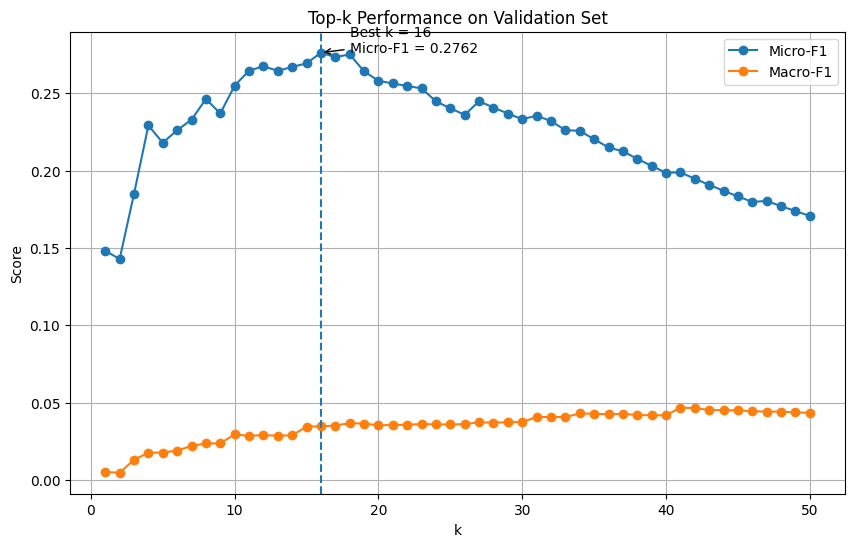

In [61]:
import matplotlib.pyplot as plt

plot_df = topk_result["tuning_df"].sort_values("k")

plt.figure(figsize=(10, 6))
plt.plot(plot_df["k"], plot_df["micro_f1"], marker="o", label="Micro-F1")
plt.plot(plot_df["k"], plot_df["macro_f1"], marker="o", label="Macro-F1")

best_row = plot_df.loc[plot_df["micro_f1"].idxmax()]
best_k = int(best_row["k"])
best_micro_f1 = float(best_row["micro_f1"])

plt.axvline(best_k, linestyle="--")
plt.annotate(
    f"Best k = {best_k}\nMicro-F1 = {best_micro_f1:.4f}",
    xy=(best_k, best_micro_f1),
    xytext=(best_k + 2, best_micro_f1),
    arrowprops=dict(arrowstyle="->")
)

plt.xlabel("k")
plt.ylabel("Score")
plt.title("Top-k Performance on Validation Set")
plt.legend()
plt.grid(True)
plt.show()